In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.18.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
DATASET_FILE = "pneumoniamnist_128.npz"

data = np.load(DATASET_FILE)

print(data.files)

['train_images', 'train_labels', 'val_images', 'val_labels', 'test_images', 'test_labels']


In [3]:
X_train = data["train_images"]
y_train = data["train_labels"]

X_val = data["val_images"]
y_val = data["val_labels"]

X_test = data["test_images"]
y_test = data["test_labels"]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (4708, 128, 128) (4708, 1)
Validation: (524, 128, 128) (524, 1)
Test: (624, 128, 128) (624, 1)


In [4]:
y_train = y_train.squeeze()
y_val = y_val.squeeze()
y_test = y_test.squeeze()

print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

print("Train classes:", np.unique(y_train, return_counts=True))
print("Validation classes:", np.unique(y_val, return_counts=True))
print("Test classes:", np.unique(y_test, return_counts=True))

(4708,)
(524,)
(624,)
Train classes: (array([0, 1], dtype=uint8), array([1214, 3494]))
Validation classes: (array([0, 1], dtype=uint8), array([135, 389]))
Test classes: (array([0, 1], dtype=uint8), array([234, 390]))


In [5]:
CLASS_NAMES = ["Normal", "Pneumonia"]

print("0 =", CLASS_NAMES[0])
print("1 =", CLASS_NAMES[1])

0 = Normal
1 = Pneumonia


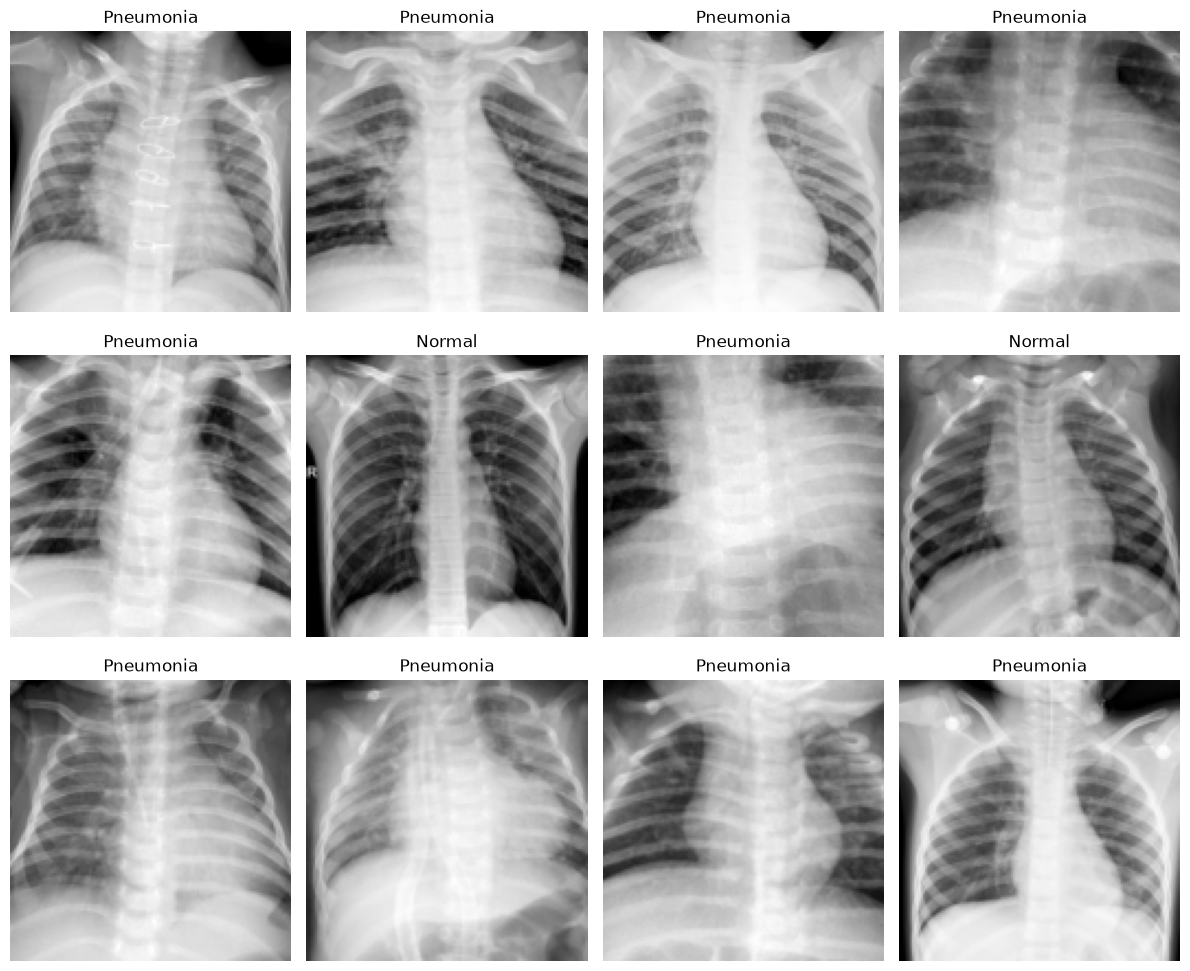

In [6]:
plt.figure(figsize=(12, 10))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        X_train[i],
        cmap="gray"
    )

    plt.title(
        CLASS_NAMES[int(y_train[i])]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
print("Data type:", X_train.dtype)
print("Minimum:", X_train.min())
print("Maximum:", X_train.max())

Data type: uint8
Minimum: 0
Maximum: 255


In [8]:
IMG_SIZE = 128
BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE

In [9]:
def prepare_image(image, label):

    image = tf.cast(
        image,
        tf.float32
    )

    # Add channel dimension:
    # 128x128 -> 128x128x1
    image = tf.expand_dims(
        image,
        axis=-1
    )

    # Grayscale -> RGB
    image = tf.image.grayscale_to_rgb(
        image
    )

    label = tf.cast(
        label,
        tf.float32
    )

    return image, label

In [10]:
def make_dataset(
    images,
    labels,
    training=False
):

    ds = tf.data.Dataset.from_tensor_slices(
        (images, labels)
    )

    if training:

        ds = ds.shuffle(
            buffer_size=len(images),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        prepare_image,
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(
        BATCH_SIZE
    )

    ds = ds.prefetch(
        AUTOTUNE
    )

    return ds

In [11]:
train_ds = make_dataset(
    X_train,
    y_train,
    training=True
)

val_ds = make_dataset(
    X_val,
    y_val,
    training=False
)

test_ds = make_dataset(
    X_test,
    y_test,
    training=False
)

2026-09-27 19:22:32.585149: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-09-27 19:22:32.585422: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-09-27 19:22:32.585440: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
I0000 00:00:1790517152.585808  125955 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1790517152.586025  125955 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [12]:
images, labels = next(
    iter(train_ds)
)

print("Images:", images.shape)
print("Labels:", labels.shape)

print(
    "Pixel range:",
    tf.reduce_min(images).numpy(),
    tf.reduce_max(images).numpy()
)

Images: (32, 128, 128, 3)
Labels: (32,)
Pixel range: 0.0 254.0


In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(
        0.03
    ),

    tf.keras.layers.RandomTranslation(
        height_factor=0.03,
        width_factor=0.03
    ),

    tf.keras.layers.RandomZoom(
        0.05
    )
])

In [14]:
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    )
)

base_model.trainable = False

print(
    "ResNet50 loaded."
)

ResNet50 loaded.


In [15]:
inputs = tf.keras.Input(
    shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    )
)

x = data_augmentation(
    inputs
)

x = tf.keras.applications.resnet50.preprocess_input(
    x
)

x = base_model(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(
    x
)

x = tf.keras.layers.Dropout(
    0.30
)(x)

x = tf.keras.layers.Dense(
    128,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(
    0.20
)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 128, 128,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 128, 128)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 128, 128)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 128, 128)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 128, 128,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 4, 4,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [16]:
normal_count = np.sum(
    y_train == 0
)

pneumonia_count = np.sum(
    y_train == 1
)

total = len(y_train)

class_weight = {
    0: total / (2 * normal_count),
    1: total / (2 * pneumonia_count)
}

print("Normal:", normal_count)
print("Pneumonia:", pneumonia_count)

print(
    "Class weights:",
    class_weight
)

Normal: 1214
Pneumonia: 3494
Class weights: {0: np.float64(1.9390444810543657), 1: np.float64(0.6737263880938752)}


In [17]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0005
)

model.compile(
    optimizer=optimizer,

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.AUC(
            name="auc"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

In [18]:
os.makedirs(
    "models",
    exist_ok=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "models/best_pneumonia_resnet.keras",

    monitor="val_auc",

    mode="max",

    save_best_only=True,

    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",

    mode="max",

    patience=4,

    restore_best_weights=True,

    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",

    factor=0.5,

    patience=2,

    min_lr=1e-6,

    verbose=1
)

In [19]:
history = model.fit(
    train_ds,

    validation_data=val_ds,

    epochs=15,

    class_weight=class_weight,

    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ]
)

Epoch 1/15


/opt/anaconda3/envs/melanoma_gpu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-09-27 19:26:03.675595: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8927 - auc: 0.9576 - loss: 0.3347 - precision: 0.9611 - recall: 0.8915
Epoch 1: val_auc improved from None to 0.97269, saving model to models/best_pneumonia_resnet.keras

Epoch 1: finished saving model to models/best_pneumonia_resnet.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 36s 201ms/step - accuracy: 0.8927 - auc: 0.9576 - loss: 0.3347 - precision: 0.9611 - recall: 0.8915 - val_accuracy: 0.8760 - val_auc: 0.9727 - val_loss: 0.3883 - val_precision: 0.9793 - val_recall: 0.8509 - learning_rate: 5.0000e-04
Epoch 2/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9216 - auc: 0.9709 - loss: 0.2770 - precision: 0.9719 - recall: 0.9210
Epoch 2: val_auc improved from 0.97269 to 0.97505, saving model to models/best_pneumonia_resnet.keras

Epoch 2: finished saving model to models/best_pneumonia_resnet.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 26s 173ms/step - accuracy: 0.9216 - auc: 0.9709 - loss: 0.2770 - precision: 0.9719 - recall: 0.9210 -

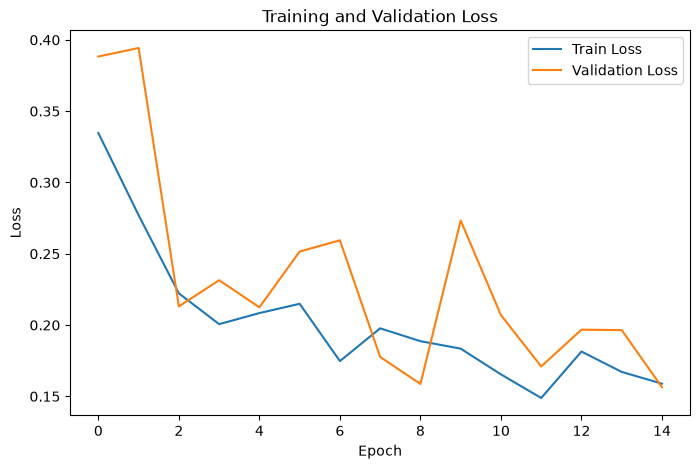

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

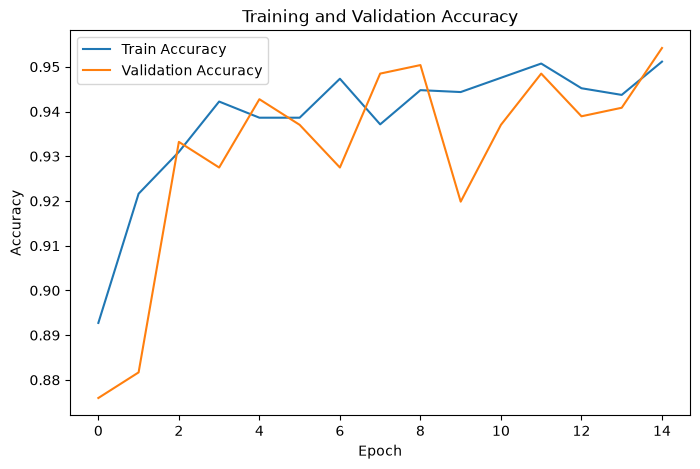

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

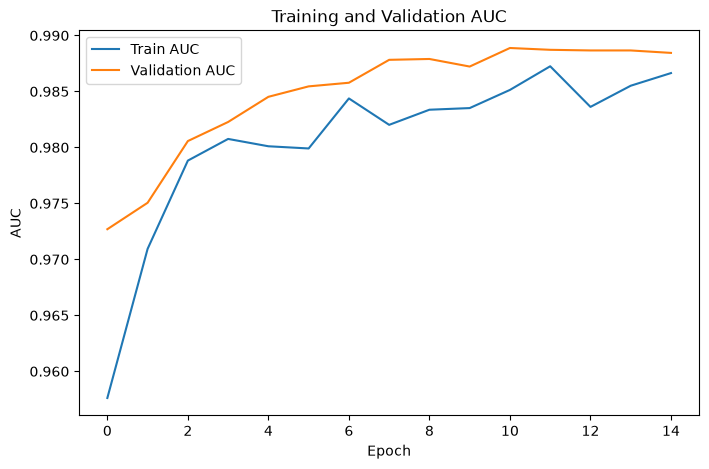

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["auc"],
    label="Train AUC"
)

plt.plot(
    history.history["val_auc"],
    label="Validation AUC"
)

plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Training and Validation AUC")

plt.legend()
plt.show()

In [23]:
best_model = tf.keras.models.load_model(
    "models/best_pneumonia_resnet.keras"
)

print(
    "Best model loaded successfully."
)

Best model loaded successfully.


In [24]:
train_results = best_model.evaluate(
    train_ds,
    verbose=1
)

print("\nTRAIN RESULTS")

for name, value in zip(
    best_model.metrics_names,
    train_results
):
    print(name, ":", value)

148/148 ━━━━━━━━━━━━━━━━━━━━ 23s 137ms/step - accuracy: 0.9511 - auc: 0.9923 - loss: 0.1595 - precision: 0.9933 - recall: 0.9405

TRAIN RESULTS
loss : 0.15949589014053345
compile_metrics : 0.9511469602584839


In [25]:
val_results = best_model.evaluate(
    val_ds,
    verbose=1
)

print("\nVALIDATION RESULTS")

for name, value in zip(
    best_model.metrics_names,
    val_results
):
    print(name, ":", value)

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 165ms/step - accuracy: 0.9370 - auc: 0.9889 - loss: 0.2070 - precision: 0.9917 - recall: 0.9229

VALIDATION RESULTS
loss : 0.20695139467716217
compile_metrics : 0.9370229244232178


In [26]:
test_results = best_model.evaluate(
    test_ds,
    verbose=1
)

print("\nFINAL TEST RESULTS")

for name, value in zip(
    best_model.metrics_names,
    test_results
):
    print(name, ":", value)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.9375 - auc: 0.9780 - loss: 0.2057 - precision: 0.9398 - recall: 0.9615

FINAL TEST RESULTS
loss : 0.20565654337406158
compile_metrics : 0.9375


In [27]:
test_probabilities = best_model.predict(
    test_ds,
    verbose=1
).ravel()

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

print(
    "Number of predictions:",
    len(test_predictions)
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 246ms/step
Number of predictions: 624


In [28]:
test_auc = roc_auc_score(
    y_test,
    test_probabilities
)

print(
    "Test ROC AUC:",
    test_auc
)

Test ROC AUC: 0.9797172912557528


In [29]:
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=CLASS_NAMES,
        digits=4
    )
)

              precision    recall  f1-score   support

      Normal     0.9333    0.8974    0.9150       234
   Pneumonia     0.9398    0.9615    0.9506       390

    accuracy                         0.9375       624
   macro avg     0.9366    0.9295    0.9328       624
weighted avg     0.9374    0.9375    0.9372       624



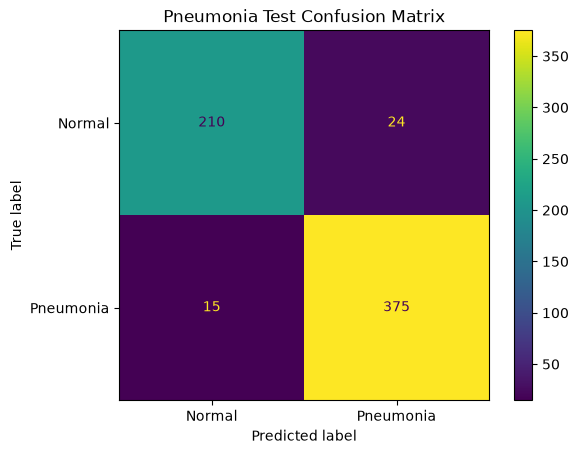

In [30]:
cm = confusion_matrix(
    y_test,
    test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

disp.plot(
    values_format="d"
)

plt.title(
    "Pneumonia Test Confusion Matrix"
)

plt.show()

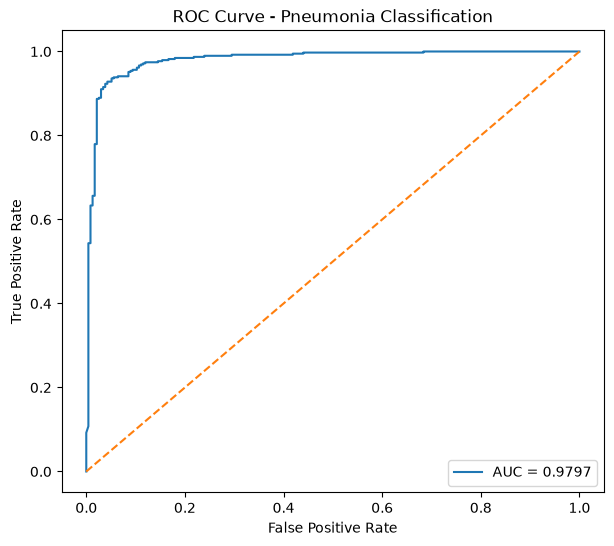

In [31]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    test_probabilities
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {test_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - Pneumonia Classification"
)

plt.legend()

plt.show()

In [32]:
train_eval = best_model.evaluate(
    train_ds,
    verbose=0,
    return_dict=True
)

test_eval = best_model.evaluate(
    test_ds,
    verbose=0,
    return_dict=True
)

print("TRAIN")
print("Accuracy:", round(train_eval["accuracy"], 4))
print("AUC:", round(train_eval["auc"], 4))
print("Loss:", round(train_eval["loss"], 4))

print("\nTEST")
print("Accuracy:", round(test_eval["accuracy"], 4))
print("AUC:", round(test_eval["auc"], 4))
print("Loss:", round(test_eval["loss"], 4))

TRAIN
Accuracy: 0.9511
AUC: 0.9923
Loss: 0.1595

TEST
Accuracy: 0.9375
AUC: 0.978
Loss: 0.2057


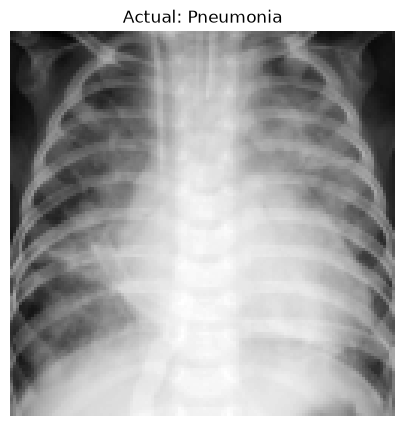

In [33]:
index = 10

image = X_test[index]

actual_label = int(
    y_test[index]
)

plt.figure(figsize=(5, 5))

plt.imshow(
    image,
    cmap="gray"
)

plt.title(
    f"Actual: {CLASS_NAMES[actual_label]}"
)

plt.axis("off")
plt.show()

In [34]:
image_input = image.astype(
    np.float32
)

image_input = np.expand_dims(
    image_input,
    axis=-1
)

image_input = np.repeat(
    image_input,
    3,
    axis=-1
)

image_input = np.expand_dims(
    image_input,
    axis=0
)

print(
    image_input.shape
)

(1, 128, 128, 3)


In [35]:
pneumonia_probability = float(
    best_model.predict(
        image_input,
        verbose=0
    )[0][0]
)

normal_probability = (
    1 - pneumonia_probability
)

if pneumonia_probability >= 0.5:

    predicted_class = "Pneumonia"

else:

    predicted_class = "Normal"

print(
    "Normal probability:",
    round(normal_probability, 4)
)

print(
    "Pneumonia probability:",
    round(pneumonia_probability, 4)
)

print(
    "Predicted:",
    predicted_class
)

print(
    "Actual:",
    CLASS_NAMES[actual_label]
)

Normal probability: 0.0
Pneumonia probability: 1.0
Predicted: Pneumonia
Actual: Pneumonia


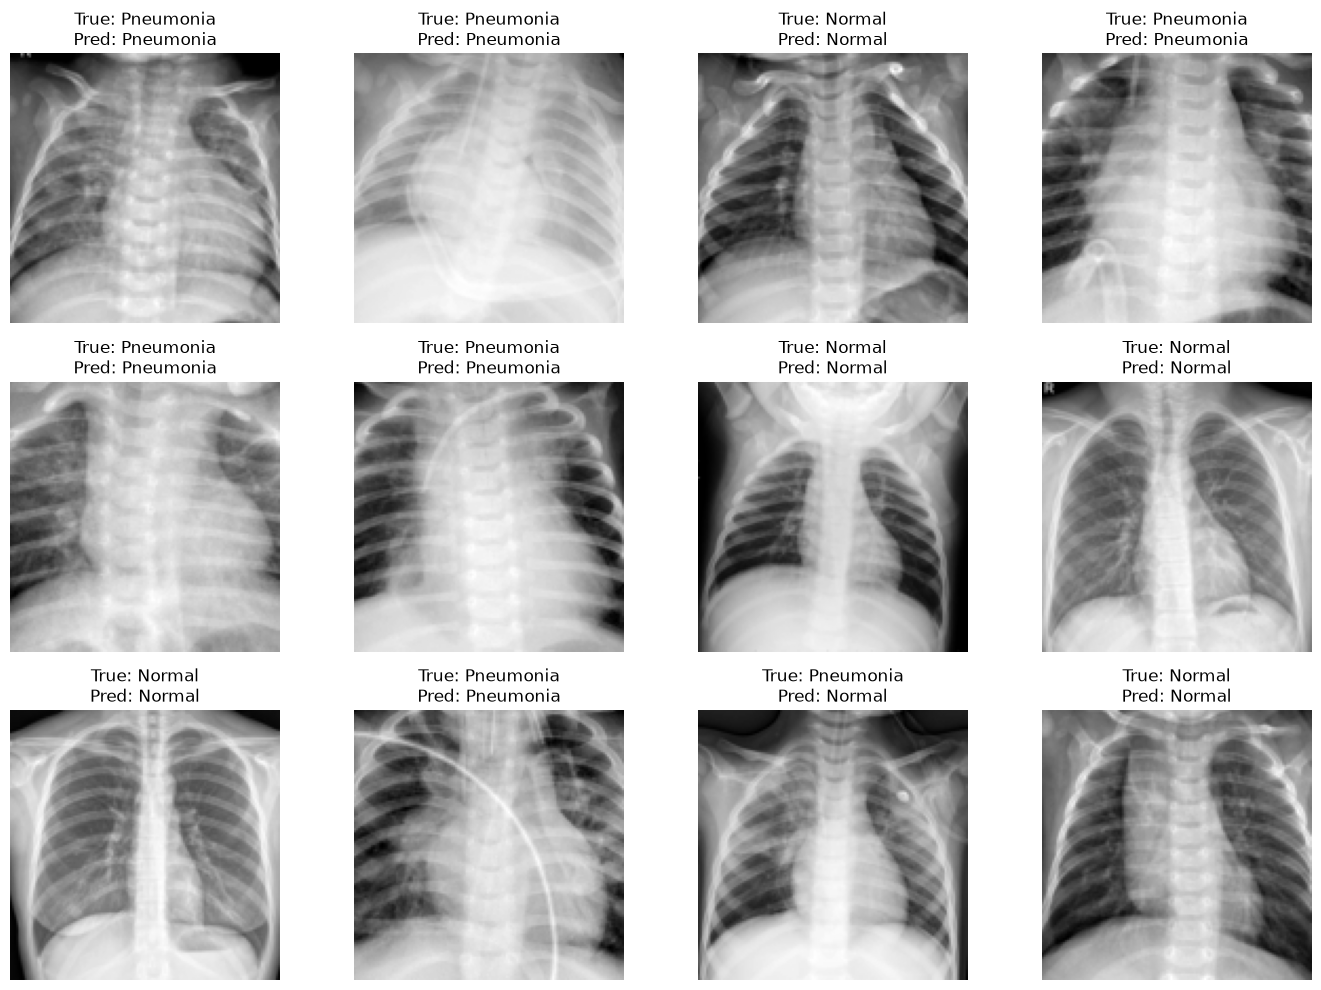

In [36]:
plt.figure(
    figsize=(14, 10)
)

indices = np.random.default_rng(
    42
).choice(
    len(X_test),
    size=12,
    replace=False
)

for i, index in enumerate(indices):

    image = X_test[index]

    actual = int(
        y_test[index]
    )

    image_input = image.astype(
        np.float32
    )

    image_input = np.expand_dims(
        image_input,
        axis=-1
    )

    image_input = np.repeat(
        image_input,
        3,
        axis=-1
    )

    probability = float(
        best_model.predict(
            image_input[np.newaxis, ...],
            verbose=0
        )[0][0]
    )

    predicted = (
        1
        if probability >= 0.5
        else 0
    )

    plt.subplot(
        3,
        4,
        i + 1
    )

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.title(
        f"True: {CLASS_NAMES[actual]}\n"
        f"Pred: {CLASS_NAMES[predicted]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()